# Thermal

*The node network the board integrates and how it was fitted, the SOA budget and a burst planned against it, the room and the air path identified on the stand-in's tour, the margin, and a trip.*

**Abstract.** The board has one thermometer that sees the power stage and a gate driver it must not cook, so it runs a twenty-node network that follows the copper and reports where every node stands; the same network is in `coaxial.model.thermal` on the host, fitted against a thermal camera in four states on 2026-08-28. This notebook reads the network and its fit back, solves its steady states and time constants, reads the board's own estimate and budget through `device.thermal`, works the envelope out - what is holdable for ever, what is a burst, how long a burst has - and then walks the stand-in's ground truth through three rooms under a load cycle for 150 model minutes while the identifier the firmware runs finds the room and the air path, and finally trips the envelope with the stage armed. What it measures: 8.33 K/W and 49 J/K for the board, a constant of 6.8 minutes; the NTC 6.0 K over the board at rest and 0.30 of the V leg's rise; 2.40 W switching dry, the supply corner the hottest node at 72 C; a continuous rating near 20 A rms a phase against the 90 % throttle point, and a 60 A burst counted in seconds; the room found to within a few kelvin at the end of every settled leg; a trip that drops the stage, caps the margin at 0.70 and gives it back in half an hour. What a reader takes to the bench: one number is measured and the rest is model, `error` is what says whether the model holds, the capacities behind every burst figure were never taken, and a power step with the NTC's slope is what would take them.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The network, and how it was fitted

`coaxial.model.thermal` carries the network `thermal/src/thermal.c` integrates: twenty nodes that follow the copper - a driver and a phase per leg, the MCU, the supply corner, the front end, the laminate as seven patches joined by a sheet conductance, the hot swap, and the motor's three behind the board. Not FEM: a mesh does not fit in a main loop and is not needed to say how hot a gate driver is. Only `board_to_ambient` and `board_capacity` have a clean measurement behind them - the passive state's 1.2 W over a 10 K rise against the supply's 50 mA, and a settling of about seven minutes. `to_board` is a spreading resistance in the laminate, a few K/W; the parts' own capacities are not measured.

In [3]:
from coaxial.model import thermal

print('ambient %.1f C assumed; board_to_ambient %.2f K/W at a %.0f K rise, '
      'board_capacity %.0f J/K, tau %.1f min'
      % (thermal.AMBIENT, thermal.CFG['board_to_ambient'], thermal.BOARD_CAL_RISE_K,
         thermal.CFG['board_capacity'], thermal.tau_minutes()))
print('%d nodes on %d edges: %d sources, %d of laminate, the hot swap, %d of motor'
      % (len(thermal.ALL_NODES), len(thermal.EDGES), len(thermal.NODES),
         len(thermal.LAMINATE), len(thermal.MOTOR)))
for node in thermal.NODES:
    print('%-12s to_board %5.1f K/W  capacity %.3f J/K'
          % (node, thermal.CFG['to_board'][node], thermal.CFG['capacity'][node]))

ambient 25.0 C assumed; board_to_ambient 8.33 K/W at a 10 K rise, board_capacity 49 J/K, tau 6.8 min
20 nodes on 30 edges: 9 sources, 7 of laminate, the hot swap, 3 of motor
driver_u     to_board  12.0 K/W  capacity 0.117 J/K
driver_v     to_board  12.0 K/W  capacity 0.117 J/K
driver_w     to_board  12.0 K/W  capacity 0.117 J/K
phase_u      to_board   8.0 K/W  capacity 0.400 J/K
phase_v      to_board   8.0 K/W  capacity 0.400 J/K
phase_w      to_board   8.0 K/W  capacity 0.400 J/K
mcu          to_board  22.5 K/W  capacity 0.900 J/K
regulators   to_board  15.0 K/W  capacity 0.800 J/K
afe          to_board  41.5 K/W  capacity 0.300 J/K


The camera campaign held four states, each adding one power term to the one before - passive, the AFE on, DAQ traffic, three legs switching at 50 % - so the differences isolate a subsystem no single state can; each was held 25 minutes, 3.7 times the board's constant, with dead soldermask as the reference surface. The NTC sits in the drivers' hot spot: an offset over the board taken in the passive state, and a share of the V leg's rise that is geometry now - the element 8.2 mm from the V driver and 15 to 18 mm from its FETs on the pick and place, power-weighted to 0.30. The switching state then misses by a residual the module keeps as a number rather than absorbing it into a coupling.

In [4]:
print(thermal.MEASURED)
for state in thermal.STATES:
    print('%-8s %s' % (state, thermal.STATE_IS[state]))
watts = sum(thermal.POWER_SWITCHING[n] for n in thermal.DRIVERS)
print('NTC_OFFSET        %.2f K over the board, passive' % thermal.NTC_OFFSET)
print('NTC_SEES_DRIVERS  %.2f of the V leg\'s rise; the element lags %.0f s'
      % (thermal.NTC_SEES_DRIVERS, thermal.NTC_TAU_S))
print('drivers switching %.2f W over three legs = %.2f W a leg x %.0f K/W = %.1f K over the patch'
      % (watts, thermal.DRIVER_SWITCH_WATT, thermal.LEG_TO_BOARD, thermal.DRIVER_RISE_SWITCHING))
print('NTC while switching %.1f - %.1f - %.1f = %.1f K over the offset; the element accounts for '
      '%.2f x %.1f = %.2f K; residual %.2f K, a thermistor against a camera'
      % (thermal.MEASURED['switching']['ntc'], thermal.MEASURED['switching']['board'],
         thermal.NTC_OFFSET, thermal.MEASURED['switching']['ntc']
         - thermal.MEASURED['switching']['board'] - thermal.NTC_OFFSET,
         thermal.NTC_SEES_DRIVERS, thermal.DRIVER_RISE_SWITCHING,
         thermal.NTC_SEES_DRIVERS * thermal.DRIVER_RISE_SWITCHING,
         thermal.NTC_CAMPAIGN_RESIDUAL_K))

{'passive': {'ntc': 36.0, 'board': 30.0}, 'switching': {'ntc': 55.6, 'board': 40.0}}
passive  AFE off: the drivers have supply, no PWM
afe      AFE on: drivers unpowered, sensors alive, no traffic
traffic  AFE on: DAQ at full tilt, data off the board
switch   AFE off: three legs at 50 %
NTC_OFFSET        6.00 K over the board, passive
NTC_SEES_DRIVERS  0.30 of the V leg's rise; the element lags 215 s
drivers switching 0.60 W over three legs = 0.20 W a leg x 28 K/W = 5.6 K over the patch
NTC while switching 55.6 - 40.0 - 6.0 = 9.6 K over the offset; the element accounts for 0.30 x 5.6 = 1.68 K; residual 13.92 K, a thermistor against a camera


`calibrate` is the fit itself: `to_board = (T_zone - T_reference) / P_zone`, one division per node, the camera's surface at each source against the reference patch at the same moment. No least squares. The housekeeping zones come out of the passive state, where nothing switches; the bridge comes out of the difference between the switching state and the passive one, and the camera saw one bridge zone, so it constrains the three legs together. A leg alone is a hip shot between that and the datasheet's coupon, and the module says so.

In [5]:
import math

passive_power = {'mcu': thermal.POWER_SWITCHING['mcu'],
                 'regulators': thermal.POWER_SWITCHING['regulators'] - watts}
camera_passive = {'mcu': 30.0 + 15.0, 'regulators': 30.0 + 8.0}    # state 1, dead soldermask 30.0 C
fit = thermal.calibrate(camera_passive, board_c=30.0, power=passive_power)
for node, k_per_w in sorted(fit.items()):
    print('%-12s %5.1f K/W from the camera, %5.1f in the graph'
          % (node, k_per_w, thermal.CFG['to_board'][node]))
bridge_lumped = (10.1 - 1.0) / watts                # the bridge zone, state 4 less state 1
camera_leg = 3.0 * bridge_lumped
sheet_leg = 25.9 - 0.69 - thermal.CFG['board_to_ambient']
print('bridge       %5.1f K/W lumped for three legs, %.1f a leg in parallel'
      % (bridge_lumped, camera_leg))
print('a leg        %.1f K/W off the camera against %.1f off the datasheet coupon; '
      'geometric mean %.1f, carried as %.0f'
      % (camera_leg, sheet_leg, math.sqrt(camera_leg * sheet_leg), thermal.LEG_TO_BOARD))

mcu           22.5 K/W from the camera,  22.5 in the graph
regulators    15.0 K/W from the camera,  15.0 in the graph
bridge        15.2 K/W lumped for three legs, 45.5 a leg in parallel
a leg        45.5 K/W off the camera against 16.9 off the datasheet coupon; geometric mean 27.7, carried as 28


The steady state while switching dry, the whole graph relaxed, and where the NTC's element is heading - the weighted average of the V patch and the centre it is tied between. Drawn as the THERMAL OBSERVER page draws it: `coaxial.draw.thermalmap` in colour, rasterised by `coaxial.draw.ansi.image` in the bench's own faces. The scale is fixed, so a colour is a temperature in every picture.

power while switching, dry: 2.40 W
driver_u      46.93 C
driver_v      43.72 C
driver_w      42.31 C
phase_u       44.53 C
phase_v       41.32 C
phase_w       39.91 C
mcu           59.12 C
regulators    72.32 C
afe           38.27 C
board         44.13 C
hotswap       37.30 C
patch_u       44.53 C
patch_v       41.32 C
patch_w       39.91 C
patch_left    55.31 C
patch_bottom  38.27 C
patch_right   37.30 C
winding       25.00 C
stator        25.00 C
rotor         25.00 C
NTC expected 43.29 C between the centre and the V patch
settled: 1 min 14 %, 5 min 52 %, 10 min 77 %, 25 min 97 %


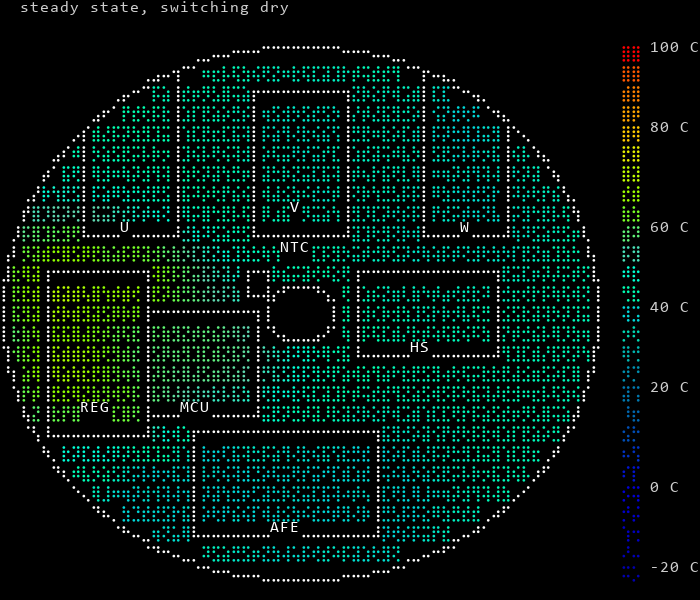

In [6]:
from coaxial.draw import ansi, thermalmap

steady = thermal.steady(thermal.POWER_SWITCHING)
print('power while switching, dry: %.2f W' % sum(thermal.POWER_SWITCHING.values()))
for node in thermal.ALL_NODES:
    print('%-12s %6.2f C' % (node, steady[node]))
ntc_steady = thermal.expected_ntc(steady['board'], steady[thermal.NTC_PATCH] - steady['board'])
print('NTC expected %.2f C between the centre and the V patch' % ntc_steady)
print('settled: ' + ', '.join('%d min %.0f %%' % (m, 100 * thermal.settled_fraction(m))
                              for m in (1, 5, 10, 25)))
ansi.image(thermalmap.render({n: steady[n] for n in thermal.NODES}, steady['board'],
                             cells=60, colour=True, title='steady state, switching dry'))

## 3 The board's own estimate, and its budget

The board runs the same network on one measurement and nineteen estimates. The NTC is the only thermometer that sees the power stage; the AFE's and the MCU's dies anchor the nodes they sit on. `state()` answers the nodes in degrees and `error`, the model's expected NTC minus the measured one - the only number that says whether the parameters hold. `ntc` is None while AFE_ON is low, which is when the drivers have supply: the sensor and the drivers share one switch, and the model then runs open on power and time. `budget()` answers `used`, a fraction of each node's span from the room to its ceiling, because a temperature cannot say how close a part is without its limit beside it; the ceilings are the calibration record's, and a node with none is not judged (invariant 10). `set_sample` is how often the observer borrows AFE_ON for a reading when nothing else holds the rail.

In [7]:
observer = device.thermal
st = observer.state()
print('NTC %s C  ambient %.1f C (estimated)  expected NTC %.2f C  error %s  settled %s'
      % (st['ntc'], st['ambient'], st['expected_ntc'], st['error'], st['settled']))
print('other dies: afe %s C, mcu %s C, seen %.1f s ago; %d integration steps'
      % (st['afe'], st['mcu'], st['seen_s_ago'], st['steps']))
cal = device.calibration.read()
budget = observer.budget()
limits = dict(zip(thermal.ALL_NODES, cal['soa_limit_c']))
print('ceilings written in the record: %d, throttle at %.2f; the defaults in force: '
      'silicon %.0f C, laminate %.0f, motor %.0f'
      % (len(limits), cal['soa_throttle_at'], thermal.CEILING_DEFAULT_C,
         thermal.CEILING_C['board'], thermal.CEILING_C['winding']))
for node in thermal.ALL_NODES:
    print('%-12s %6.2f C  used %5.1f %%  ceiling %s'
          % (node, st['nodes'][node], 100.0 * budget['used'][node],
             '%.1f C' % limits[node] if node in limits else 'none written'))
print('worst %s at %.1f %% of its span; throttling %s, tripped %s, trips %d, derate %.2f'
      % (budget['worst_node'], 100.0 * budget['worst'], budget['throttling'],
         budget['tripped'], budget['trips'], budget['derate']))
print('sample every 30 s:', observer.set_sample(30.0, settle_s=0.5),
      observer.state()['sample_every_s'])

NTC 25.0 C  ambient 25.0 C (estimated)  expected NTC 25.00 C  error 0.0  settled True
other dies: afe 25.0 C, mcu 25.0 C, seen 0.4 s ago; 1200 integration steps
ceilings written in the record: 0, throttle at 0.00; the defaults in force: silicon 125 C, laminate 105, motor 120
driver_u      25.00 C  used   0.0 %  ceiling none written
driver_v      25.00 C  used   0.0 %  ceiling none written
driver_w      25.00 C  used   0.0 %  ceiling none written
phase_u       25.00 C  used   0.0 %  ceiling none written
phase_v       25.00 C  used   0.0 %  ceiling none written
phase_w       25.00 C  used   0.0 %  ceiling none written
mcu           25.00 C  used   0.0 %  ceiling none written
regulators    25.00 C  used   0.0 %  ceiling none written
afe           25.00 C  used   0.0 %  ceiling none written
board         25.00 C  used   0.0 %  ceiling none written
hotswap       25.00 C  used   0.0 %  ceiling none written
patch_u       25.00 C  used   0.0 %  ceiling none written
patch_v       25.00 C  used 

Every node at the room and `used` at zero: a board that has switched nothing since it was powered has nothing to report but the room it believes it stands in, and `error` is zero because the expected NTC and the measured one are the same reading. No ceiling is written in this record, so the envelope acts on the record's defaults - 125 C for silicon, 105 for the laminate, 120 for the motor - trimmed by the margin of section 5.

## 4 The envelope

Four states the board sits in, from the same network: quiet, switching dry, switching under current, and cooling. Housekeeping - the MCU and the regulators - is there in all of them; the drivers' share appears with the PWM and conduction with the current, split by `phase_power` between the FET and the shunt it sits in series with, 1.8 mOhm against 3.5. The throttle point is 90 % of the span from the room to the ceiling, 115 C for silicon in a 25 C room. Where the worst node's equilibrium reaches it is the current the board holds for ever; everything above it is timed by the board's own envelope.

In [8]:
from coaxial.model import inverter, motor
from coaxial.devices.thermal_device import THROTTLE_AT

R_PHASE = inverter.RDS_ON + inverter.SHUNT
THROTTLE_C = thermal.AMBIENT + THROTTLE_AT * (thermal.CEILING_DEFAULT_C - thermal.AMBIENT)
STATES = (('quiet, no PWM', 0.0, False),
          ('switching, no current', 0.0, True),
          ('switching, 10 A of iq', 10.0, True),
          ('switching, 20 A of iq', 20.0, True),
          ('switching, 60 A of iq', 60.0, True))
print('%-24s %6s %8s %10s %11s   %s' % ('', 'W', 'board C', 'worst C', 'which', 'holdable'))
holdable = {}
for name, iq, on in STATES:
    power = thermal.phase_power(iq / math.sqrt(2.0), R_PHASE, switching=on)
    at = thermal.steady(power)
    worst = max(thermal.NODES, key=lambda n: at[n])
    holdable[name] = (at, at[worst] <= THROTTLE_C)
    print('%-24s %6.2f %8.1f %10.1f %11s   %s'
          % (name, sum(power.values()), at['board'], at[worst], thermal.pretty(worst),
             'yes' if holdable[name][1] else 'NO - a burst, timed below'))
rms = thermal.continuous_amps(R_PHASE, THROTTLE_C)
iq_cont = rms * math.sqrt(2.0)
at = thermal.steady(thermal.phase_power(rms, R_PHASE))
print('continuous: %.1f A rms a phase = %.1f A of iq = %.2f N.m on the bench motor; '
      'worst node %.1f C against the %.1f C throttle point, board %.1f C'
      % (rms, iq_cont, motor.KT_NM_PER_AMP * iq_cont,
         max(at[n] for n in thermal.NODES), THROTTLE_C, at['board']))

                              W  board C    worst C       which   holdable
quiet, no PWM              1.80     41.6       69.7  regulators   yes
switching, no current      2.40     44.1       72.3  regulators   yes
switching, 10 A of iq      3.19     47.1       75.4  regulators   yes
switching, 20 A of iq      5.58     55.1       83.7  regulators   yes
switching, 60 A of iq     31.02    106.5      299.8     phase U   NO - a burst, timed below


continuous: 20.0 A rms a phase = 28.3 A of iq = 1.23 N.m on the bench motor; worst node 115.0 C against the 115.0 C throttle point, board 64.1 C


Equilibrium is where a holdable state ends up, and the board's own constant decides how long that takes; a node reaches its rise over the board far sooner. A burst is over long before either constant matters: a node climbs at `P / capacity` from wherever it started, and what stops it is the ceiling in the record, throttled at 90 %. The capacities are the one number nobody took - `thermal.py` says so at length - so the seconds are a band, up to three times shorter by Silva's transient factor of a third.

In [9]:
tau_board = thermal.tau_minutes()
print('board       %.0f J/K over %.2f K/W = %.1f min'
      % (thermal.CFG['board_capacity'], thermal.CFG['board_to_ambient'], tau_board))
tau_node = {}
for node in ('driver_u', 'phase_u', 'mcu'):
    tau_node[node] = thermal.CFG['capacity'][node] * thermal.CFG['to_board'][node]
    print('%-11s %.2f J/K over %.1f K/W = %.1f s'
          % (thermal.pretty(node), thermal.CFG['capacity'][node],
             thermal.CFG['to_board'][node], tau_node[node]))
print()
print('  iq A   W on the FET node   K/s   W on the shunt   K/s   s to the throttle point from ambient   from a warm board (60 C)')
burst = {}
for iq in (20.0, 40.0, 60.0, 100.0):
    power = thermal.phase_power(iq / math.sqrt(2.0), R_PHASE)   # the FET's conduction and switching, the shunt's conduction
    fet, shunt = power['driver_u'], power['phase_u']
    slope = max(fet / thermal.CFG['capacity']['driver_u'], shunt / thermal.CFG['capacity']['phase_u'])
    burst[iq] = (fet, shunt, slope, (THROTTLE_C - thermal.AMBIENT) / slope, (THROTTLE_C - 60.0) / slope)
    print('%7.0f %17.1f %5.1f %16.1f %5.1f %38.2f %26.2f'
          % (iq, fet, fet / thermal.CFG['capacity']['driver_u'], shunt,
             shunt / thermal.CFG['capacity']['phase_u'], burst[iq][3], burst[iq][4]))

board       49 J/K over 8.33 K/W = 6.8 min
driver U    0.12 J/K over 12.0 K/W = 1.4 s
phase U     0.40 J/K over 8.0 K/W = 3.2 s
mcu         0.90 J/K over 22.5 K/W = 20.2 s

  iq A   W on the FET node   K/s   W on the shunt   K/s   s to the throttle point from ambient   from a warm board (60 C)
     20               0.6   4.8              0.7   1.8                                  18.75                      11.46
     40               1.6  14.1              2.8   7.0                                   6.40                       3.91
     60               3.4  29.5              6.3  15.7                                   3.05                       1.87
    100               9.2  78.9             17.5  43.7                                   1.14                       0.70


The same plan against where the observer says a node stands now, in the record's terms: a node's rise over the board is `P * to_board`, reached on its own constant `capacity * to_board`, while the board rises on 6.8 minutes. The seconds to the throttle point follow from the same arithmetic, from the node's present estimate. And cooling: with the current off a node dumps into the board on its own constant, and the board loses what it has to the room on 6.8 minutes - the node is cold in seconds, the board is what a second burst waits for.

In [10]:
def rise_after(node, watts, seconds):
    tau = thermal.CFG['capacity'][node] * thermal.CFG['to_board'][node]
    return watts * thermal.CFG['to_board'][node] * (1.0 - math.exp(-seconds / tau))

def seconds_to(node, watts, now_c, ceiling_c):
    tau = thermal.CFG['capacity'][node] * thermal.CFG['to_board'][node]
    top = now_c + watts * thermal.CFG['to_board'][node]
    if top <= ceiling_c:
        return None
    return -tau * math.log(1.0 - (ceiling_c - now_c) / (top - now_c))

def cools_in(rise_k, tau_s, to_k=1.0):
    return tau_s * math.log(rise_k / to_k) if rise_k > to_k else 0.0

for node in ('phase_u', 'driver_u', 'mcu'):
    for watts in (5.0, 15.0, 35.0):
        t = seconds_to(node, watts, st['nodes'][node], THROTTLE_C)
        print('%-9s %5.1f W: +%5.1f K after 100 ms, +%6.1f K steady; the %.0f C throttle point from %.1f C: %s'
              % (node, watts, rise_after(node, watts, 0.1), watts * thermal.CFG['to_board'][node],
                 THROTTLE_C, st['nodes'][node], 'never' if t is None else '%.2f s' % t))
print()
cooling = {}
for node in ('driver_u', 'phase_u'):
    cooling[node] = [cools_in(THROTTLE_C - thermal.AMBIENT, tau_node[node], target) for target in (20.0, 5.0, 1.0)]
    print('%-9s after a burst to the throttle point: to +20 K over the board in %.1f s, +5 K in %.1f, +1 K in %.1f'
          % (node, cooling[node][0], cooling[node][1], cooling[node][2]))
board_cools = {}
for name, iq, on in STATES:
    at, holds = holdable[name]
    if not holds:
        continue
    board_cools[name] = (at['board'] - thermal.AMBIENT, cools_in(at['board'] - thermal.AMBIENT, tau_board * 60.0) / 60.0)
    print('board after %-24s +%5.1f K, back to +1 K in %.0f min' % (name + ':', board_cools[name][0], board_cools[name][1]))

phase_u     5.0 W: +  1.2 K after 100 ms, +  40.0 K steady; the 115 C throttle point from 25.0 C: never
phase_u    15.0 W: +  3.7 K after 100 ms, + 120.0 K steady; the 115 C throttle point from 25.0 C: 4.44 s
phase_u    35.0 W: +  8.6 K after 100 ms, + 280.0 K steady; the 115 C throttle point from 25.0 C: 1.24 s
driver_u    5.0 W: +  4.1 K after 100 ms, +  60.0 K steady; the 115 C throttle point from 25.0 C: never
driver_u   15.0 W: + 12.4 K after 100 ms, + 180.0 K steady; the 115 C throttle point from 25.0 C: 0.97 s
driver_u   35.0 W: + 29.0 K after 100 ms, + 420.0 K steady; the 115 C throttle point from 25.0 C: 0.34 s
mcu         5.0 W: +  0.6 K after 100 ms, + 112.5 K steady; the 115 C throttle point from 25.0 C: 32.59 s
mcu        15.0 W: +  1.7 K after 100 ms, + 337.5 K steady; the 115 C throttle point from 25.0 C: 6.28 s
mcu        35.0 W: +  3.9 K after 100 ms, + 787.5 K steady; the 115 C throttle point from 25.0 C: 2.46 s

driver_u  after a burst to the throttle point: to +20 K

## 5 The tour: the room, the air path and the capacity identified

The stand-in is a hypothetical board with a ground truth: the same twenty-node graph in a situation - a room, a scale on the air path, one on the laminate's capacity - read through three noisy thermometers every thirty seconds and identified by the identifier the firmware runs (`coaxial/kalman/thermal_ident.py` mirrors `thermal/src/thermal_ident.c`). The observer is told nothing; a board has no ground truth to put in a situation, and `situation()` refuses in words there. The tour is temperate 20 C, cold -25, toasty 45, round again, moved on when the identification has held STABLE a hundred model seconds and no sooner than five minutes after the last move. The load is the page's cycle, two model minutes at 30 A and four idle, under the envelope. `fast_forward` drives the model's own clock, so the walk reads the same wherever it runs: 150 model minutes, a row a minute.

In [11]:
truth = observer.situation('tour')
print('the board, switched on at %.0f C, carried into %s at %.0f C' % (thermal.AMBIENT, truth['situation'], truth['ambient']))
print('rooms on the tour: ' + ', '.join('%s %.0f C' % (name, observer.SITUATIONS[name]['ambient'])
                                        for name in observer.TOUR))
print('the load cycle:', observer.load_cycle(on_s=120.0, off_s=240.0))
rows, faces = [], {}
last = truth['situation']
for minute in range(1, 151):
    observer.fast_forward(60.0, live=True)
    now, got, truth = observer.state(), observer.identification(), observer.truth()
    if truth['load_a']:
        faces[truth['situation']] = (minute, got['ambient'], dict(now['nodes']))   # the last loaded minute of each leg
    rows.append({'minute': minute, 'situation': truth['situation'], 'state': got['state'],
                 'margin': got['margin'], 'room': got['ambient'], 'room_sigma': got['ambient_sigma'],
                 'room_truth': truth['ambient'], 'air': got['scales']['air'],
                 'air_sigma': got['sigma']['air'], 'air_truth': truth['air'],
                 'capacity': got['scales']['capacity'], 'capacity_truth': truth['capacity'],
                 'innovation': got['innovation_k'], 'driver_u': now['nodes']['driver_u'],
                 'load_a': truth['load_a'] or 0.0})
    if truth['situation'] != last:
        print('minute %3d: %s -> %s' % (minute, last, truth['situation']))
        last = truth['situation']
stable = [r for r in rows if r['state'] == 'STABLE']
print('%d minutes STABLE of %d; final margin %.2f, room %.1f C for %.0f, air %.2f for %.2f, capacity %.2f for %.2f'
      % (len(stable), len(rows), rows[-1]['margin'], rows[-1]['room'], rows[-1]['room_truth'],
         rows[-1]['air'], rows[-1]['air_truth'], rows[-1]['capacity'], rows[-1]['capacity_truth']))

the board, switched on at 25 C, carried into temperate at 20 C
rooms on the tour: temperate 20 C, cold -25 C, toasty 45 C
the load cycle: {'amps': 30.0, 'on_s': 120.0, 'off_s': 240.0}


minute  12: temperate -> cold


minute  31: cold -> toasty


minute  47: toasty -> temperate


minute  73: temperate -> cold


minute  93: cold -> toasty


minute 112: toasty -> temperate


minute 139: temperate -> cold


16 minutes STABLE of 150; final margin 0.87, room -25.4 C for -25, air 0.98 for 0.90, capacity 1.00 for 1.00


The margin is continuous: the record's floor - 0.80 of every span - while the model is doubted whole, one when not at all, the doubt the worse of the innovation and the covariance normalised. A room step throws it to the floor within a minute, and the room's covariance goes back to its prior on the way, so the step is charged to the room and not to the air path. The tour moves on a hundred seconds of STABLE, so STABLE never lasts: the minutes it held are the minutes before each move. The board in each room under the same load, as the page draws it - the last loaded minute of each leg, one colour scale, the room in the title what the identification had found by then.

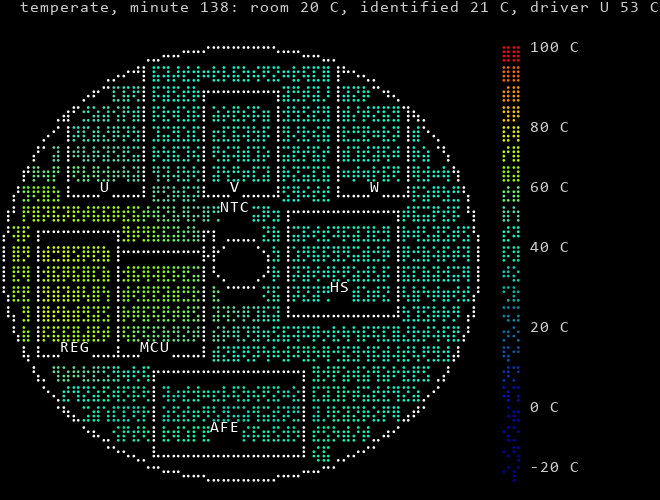

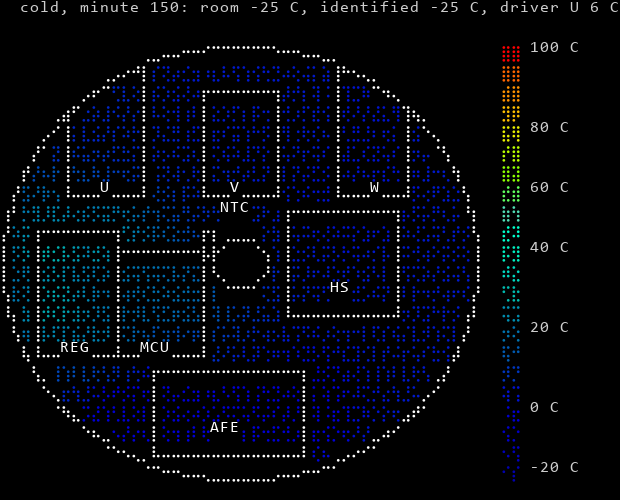

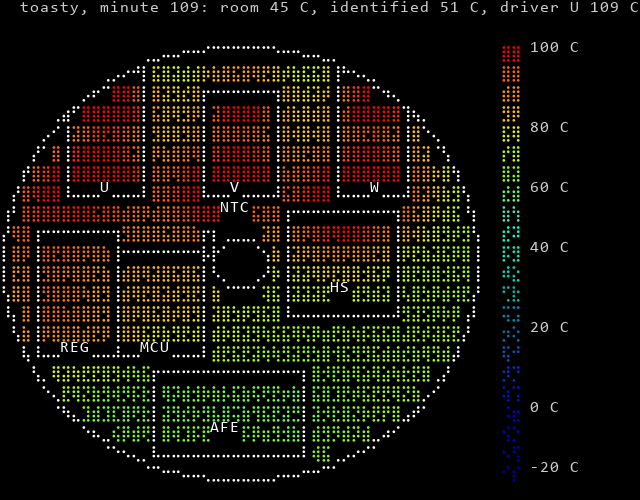

In [12]:
from IPython.display import display

for room in observer.TOUR:
    if room not in faces:
        continue
    minute, found, nodes = faces[room]
    display(ansi.image(thermalmap.render({n: nodes[n] for n in thermal.NODES}, nodes['board'],
                                         cells=48, colour=True,
                                         title='%s, minute %d: room %.0f C, identified %.0f C, driver U %.0f C'
                                               % (room, minute, observer.SITUATIONS[room]['ambient'],
                                                  found, nodes['driver_u']))))

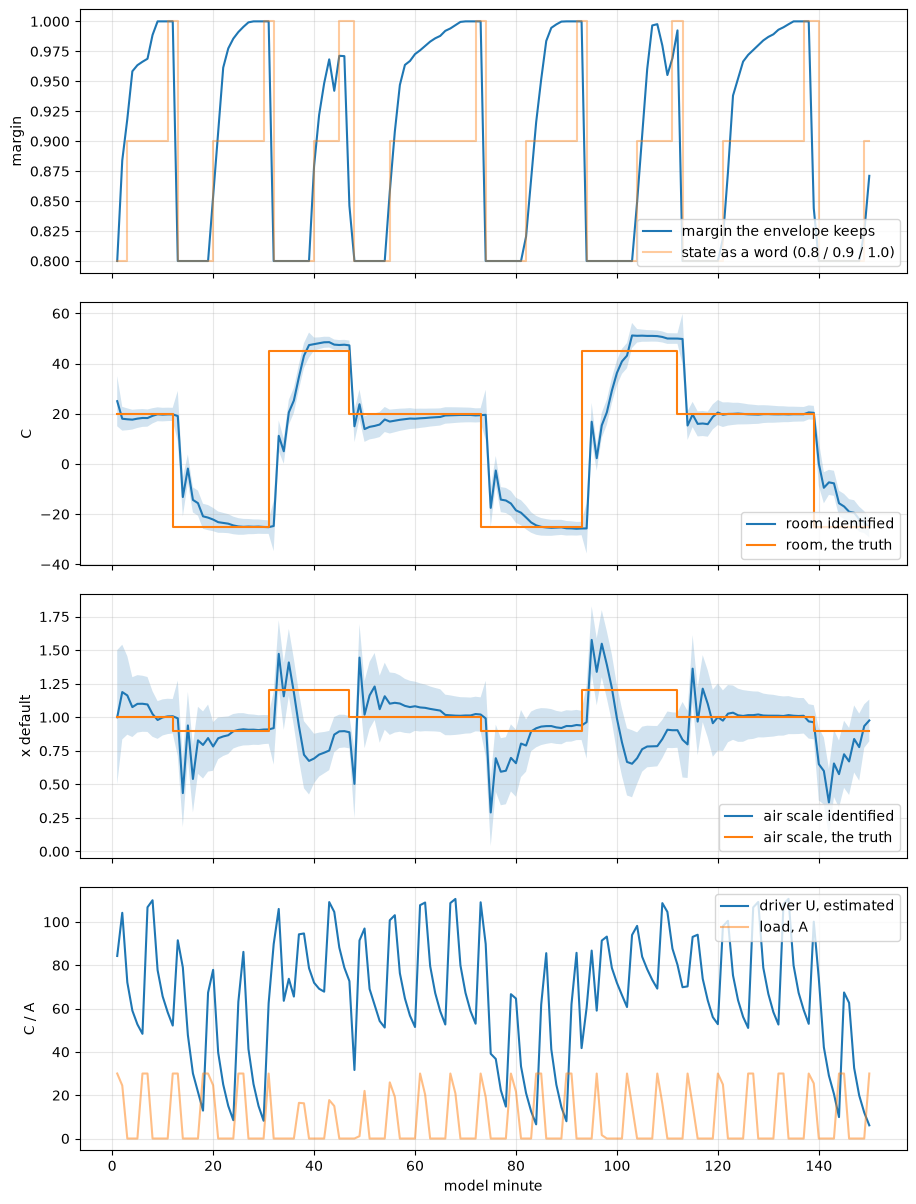

In [13]:
from coaxial.draw.figures import figure, show

t = [r['minute'] for r in rows]
fig, (top, room, air, load) = figure(rows=4, sharex=True)
top.plot(t, [r['margin'] for r in rows], label='margin the envelope keeps')
top.step(t, [{'UNCERTAIN': 0.8, 'CONVERGING': 0.9, 'STABLE': 1.0}[r['state']] for r in rows],
         where='post', alpha=0.4, label='state as a word (0.8 / 0.9 / 1.0)')
top.set_ylabel('margin')
top.legend(loc='lower right')
room.plot(t, [r['room'] for r in rows], label='room identified')
room.fill_between(t, [r['room'] - r['room_sigma'] for r in rows],
                  [r['room'] + r['room_sigma'] for r in rows], alpha=0.2)
room.step(t, [r['room_truth'] for r in rows], where='post', label='room, the truth')
room.set_ylabel('C')
room.legend(loc='lower right')
air.plot(t, [r['air'] for r in rows], label='air scale identified')
air.fill_between(t, [r['air'] - r['air_sigma'] for r in rows],
                 [r['air'] + r['air_sigma'] for r in rows], alpha=0.2)
air.step(t, [r['air_truth'] for r in rows], where='post', label='air scale, the truth')
air.set_ylabel('x default')
air.legend(loc='lower right')
load.plot(t, [r['driver_u'] for r in rows], label='driver U, estimated')
load.plot(t, [r['load_a'] for r in rows], alpha=0.5, label='load, A')
load.set_ylabel('C / A')
load.set_xlabel('model minute')
load.legend(loc='upper right')
show(fig)

## 6 A trip

A trip is the ceiling reached with the throttle already acting: the envelope drops MOE by the path the break uses, and the estimate is reported either way. After one the margin is capped at 0.70 of every span and given back a percent a minute of model time - half an hour to the identification's own - and the stage runs on less until then; re-arming is the host's. Here the stage is armed on the stand-in, the STO bypassed and the interlock ignored as the bench board needs, the load cycle is taken off, the board is carried into the cold room, and the observer is fed 200 A on three phases for two model minutes by hand, then idle for 38. `trips` counts trips and not steps: a stage already down is not dropped again.

In [14]:
print('load cycle off:', observer.load_cycle(0))
truth = observer.situation('cold')
print('carried into %s at %.0f C' % (truth['situation'], truth['ambient']))
print('stage armed:', device.gates.arm(bypass_sto=True, ignore_interlock=True)['pwm_enabled'])
cooked = {'amps': (200.0, 200.0, 200.0), 'switching': True}
idle = {'amps': (0.0, 0.0, 0.0), 'switching': False}
trace = []
for minute in range(1, 41):
    observer.fast_forward(60.0, seen=cooked if minute <= 2 else idle, live=True)
    b, got = observer.budget(), observer.identification()
    trace.append((minute, got['margin'], b['worst'], b['trips'], got['trip_cap'], device.gates.armed()))
    if minute in (1, 2, 3, 5, 10, 20, 30, 40):
        print('minute %2d: trips %d, stage armed %-5s worst %.2f of the span in force, '
              'trip cap %.2f, margin %.2f, %s'
              % (minute, b['trips'], device.gates.armed(), b['worst'], got['trip_cap'],
                 got['margin'], got['state']))
print('disarmed:', not device.gates.disarm()['pwm_enabled'])

load cycle off: {'amps': 0.0, 'on_s': 0.0, 'off_s': 0.0}
carried into cold at -25 C
stage armed: True
minute  1: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.71, margin 0.71, CONVERGING


minute  2: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.72, margin 0.72, CONVERGING
minute  3: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.73, margin 0.73, CONVERGING


minute  5: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.75, margin 0.75, STABLE


minute 10: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.80, margin 0.80, STABLE


minute 20: trips 1, stage armed False worst 1.00 of the span in force, trip cap 0.90, margin 0.90, STABLE


minute 30: trips 1, stage armed False worst 1.00 of the span in force, trip cap 1.00, margin 1.00, STABLE


minute 40: trips 1, stage armed False worst 0.61 of the span in force, trip cap 1.00, margin 1.00, STABLE
disarmed: True


One trip, and the stage is down from the first minute: the envelope dropped it, not this notebook. The cap starts at 0.70 and rises a percent a minute; the margin the envelope acts on is the smaller of that and the identification's own, so it follows the cap until the cap passes what the cooldown has earned. The worst node reads a full span for as long as it stands above the ceiling in force - a ceiling the cap pulled in - and falls below it as the board cools.

In [15]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 7 Conclusions

In [16]:
moves = [r['minute'] for a, r in zip(rows, rows[1:]) if a['situation'] != r['situation']]
before = [rows[m - 2] for m in moves]          # the minute before each move: STABLE, the leg settled
print('1. the network     %d nodes; board %.2f K/W and %.0f J/K, tau %.1f min - the two measured numbers; '
      'a leg %.0f K/W between the camera\'s %.1f and the coupon\'s %.1f'
      % (len(thermal.ALL_NODES), thermal.CFG['board_to_ambient'], thermal.CFG['board_capacity'],
         tau_board, thermal.LEG_TO_BOARD, camera_leg, sheet_leg))
print('2. the NTC         %.1f K over the board at rest, %.2f of the V leg\'s rise, lag %.0f s; '
      'the switching state misses by %.1f K'
      % (thermal.NTC_OFFSET, thermal.NTC_SEES_DRIVERS, thermal.NTC_TAU_S, thermal.NTC_CAMPAIGN_RESIDUAL_K))
print('3. the fit         mcu %.1f and regulators %.1f K/W off the passive state, the graph\'s %.1f and %.1f; '
      'bridge %.1f K/W lumped'
      % (fit['mcu'], fit['regulators'], thermal.CFG['to_board']['mcu'],
         thermal.CFG['to_board']['regulators'], bridge_lumped))
print('4. switching dry   %.2f W: board %.1f C, %s the hottest at %.1f C, NTC expected %.2f C; '
      '25 min is %.0f %% of the way'
      % (sum(thermal.POWER_SWITCHING.values()), steady['board'],
         max(thermal.NODES, key=lambda n: steady[n]), max(steady[n] for n in thermal.NODES),
         ntc_steady, 100 * thermal.settled_fraction(25)))
print('5. the board       NTC %s C, error %s, worst %s at %.1f %%; ceilings written %d, the defaults in force'
      % (st['ntc'], st['error'], budget['worst_node'], 100.0 * budget['worst'], len(limits)))
print('6. holdable        ' + '; '.join('%s: board %.1f C, worst %.1f' % (name, at['board'], max(at[n] for n in thermal.NODES))
                                        for name, (at, holds) in holdable.items() if holds))
print('7. continuous      %.1f A rms a phase = %.1f A of iq = %.2f N.m against the %.0f C throttle point'
      % (rms, iq_cont, motor.KT_NM_PER_AMP * iq_cont, THROTTLE_C))
print('8. a burst         driver %.1f s, shunt %.1f s, board %.1f min; 60 A of iq: %.1f W on the FET, %.1f on the shunt, '
      '%.0f K/s, %.1f s to the throttle point from ambient, %.1f from 60 C; cold to +1 K over the board in %.1f s'
      % (tau_node['driver_u'], tau_node['phase_u'], tau_board, burst[60.0][0], burst[60.0][1], burst[60.0][2],
         burst[60.0][3], burst[60.0][4], max(cooling['driver_u'][2], cooling['phase_u'][2])))
print('9. the board cools %s' % '; '.join('%s +%.1f K, back to +1 K in %.0f min' % (name, rise, minutes)
                                          for name, (rise, minutes) in board_cools.items()))
print('10. the tour       moved at minutes %s; STABLE %d of %d, the margin at the floor %d minutes, whole %d'
      % (moves, len(stable), len(rows), sum(1 for r in rows if r['margin'] <= 0.8 + 1e-9),
         sum(1 for r in rows if r['margin'] >= 0.999)))
print('    the room       at each leg\'s end: ' + ', '.join('%.1f for %.0f' % (r['room'], r['room_truth']) for r in before)
      + '; worst %.1f K' % max(abs(r['room'] - r['room_truth']) for r in before))
print('    the air path   at each leg\'s end: ' + ', '.join('%.2f for %.2f' % (r['air'], r['air_truth']) for r in before)
      + '; capacity %.2f for %.2f at the end' % (rows[-1]['capacity'], rows[-1]['capacity_truth']))
print('11. the trip       %d trip, stage armed after it: %s; margin %.2f the minute after, %.2f at minute 10, '
      '%.2f at 20, %.2f at 30, %.2f at 40; the cap %.2f -> %.2f'
      % (trace[-1][3], trace[0][5], trace[2][1], trace[9][1], trace[19][1], trace[29][1], trace[39][1],
         trace[0][4], trace[-1][4]))

1. the network     20 nodes; board 8.33 K/W and 49 J/K, tau 6.8 min - the two measured numbers; a leg 28 K/W between the camera's 45.5 and the coupon's 16.9
2. the NTC         6.0 K over the board at rest, 0.30 of the V leg's rise, lag 215 s; the switching state misses by 13.9 K
3. the fit         mcu 22.5 and regulators 15.0 K/W off the passive state, the graph's 22.5 and 15.0; bridge 15.2 K/W lumped
4. switching dry   2.40 W: board 44.1 C, regulators the hottest at 72.3 C, NTC expected 43.29 C; 25 min is 97 % of the way
5. the board       NTC 25.0 C, error 0.0, worst driver_u at 0.0 %; ceilings written 0, the defaults in force
6. holdable        quiet, no PWM: board 41.6 C, worst 69.7; switching, no current: board 44.1 C, worst 72.3; switching, 10 A of iq: board 47.1 C, worst 75.4; switching, 20 A of iq: board 55.1 C, worst 83.7
7. continuous      20.0 A rms a phase = 28.3 A of iq = 1.23 N.m against the 115 C throttle point
8. a burst         driver 1.4 s, shunt 3.2 s, board 6.8 min;

One measurement and nineteen estimates. The NTC is the only thermometer that sees the power stage, and `error` - the model's expected NTC minus the measured one - is the only number that says whether the parameters hold. `ntc` is None while AFE_ON is low, which is when the drivers have supply and switching is possible: the sensor and the drivers share one switch, and the model then runs open on power and time, borrowing the rail at `set_sample`'s interval when nothing else holds it; while another subsystem holds it the NTC is read every step, and an acquire is refused while the stage is armed.

This is the narrow exception to invariant 10. The board never calls a reading good - it reports the margin and *acts*, dropping MOE at a ceiling by the path the break uses. The ceilings live in the calibration record, a limit it was given rather than invented, and a node with none is not judged; an unwritten record leaves the defaults in force.

No least squares: `to_board = (T_zone - T_reference) / P_zone`, one division per node, T from a camera against a dead patch of soldermask - not the NTC, which sits in the drivers' hot spot. A spreading resistance in the laminate is a few K/W; tens means the power or the reference surface is wrong. Each state adds one power term to the one before, so the differences isolate a subsystem no single state can, and each was held 25 minutes, 3.7 times the board's constant. The camera saw one bridge zone, 15.2 K/W lumped, so it constrains the three legs together; a leg alone is three times that against the datasheet coupon's 16.9, and the module carries the geometric mean, 28, and says which measurement would replace it - a camera run under real load with the reference surface's emissivity corrected. The NTC coupling was once fitted at 1.055 from the one switching state, which no passive body can have, and capping it at 1.0 cost 5.6 K there; it is an element now, 0.30 off the pick and place, and the 13.9 K the switching state misses by is kept as a residual, a thermistor against a camera. The whole calibration was taken **dry**: at 100 A the shunt alone makes 35 W against the dry budget's 1.2 W.

The two constants are what the whole envelope rests on. A burst lives on the leg nodes' seconds and is bounded by the record's ceiling; the duty cycle a bench can hold lives on the board's 6.8 minutes, which is also what a second burst waits for. Between them the observer runs at 100 ms steps and samples the NTC every 30 s - fast against the board and slow against a burst, so the board's estimate is anchored and the node's is open-loop over the burst, by construction. The continuous number falls out of the states table: at the current where the worst node's equilibrium reaches the throttle point the state can be held for ever, and everything above it is timed. The capacities that time it were never measured, so every burst figure is a band up to three times shorter than printed.

The room is the fifth identified quantity - the board has no ambient sensor - and a cooldown is what tells a cold room from a good air path, since the room's sensitivity is the same at every rise and the air path's grows with it; two other ways of inferring it ran off (FINDINGS). The spread and the NTC scales ride at the record's values: unobservable from a cooldown, they ran to a clamp (FINDINGS, 2026-09-05). An idling board stays at the floor, since a sample whose thermometers moved less than three floors says nothing. After a trip the cap is 0.70 and the margin the envelope acts on is the least of the cap and the identification's own, so the half hour is what the stage runs on less for, whatever the identification earns in the meantime.

**At the bench.** Flip `SIMULATED` and name the port. Sections 2 and 4 are host arithmetic and read the same on any machine; section 3 is the board's own estimate, and `error` there is the first number to look at - a model whose expected NTC drifts from the measured one under a run has a parameter wrong, and `set_node` is the one division that fixes it. Compare the steady states of section 2 against a camera, with the reference on dead soldermask and the emissivity corrected, and the burst seconds of section 4 against the NTC's own slope after a power step from `tools/bench/pulse.py`: `dT/dt` right after the step is `P / capacity` directly, and that one measurement replaces the band. Sections 5 and 6 are the stand-in's: a board has no ground truth to put in a situation and refuses `situation()` and `load_cycle()` in words, so at the bench the identification is watched on the THERMAL OBSERVER page through a real cooldown, and a trip is the envelope dropping MOE under `tools/bench/switch.py` with the ceilings written into the record first. What the stand-in could not show: the NTC reading None with the drivers powered, the dies' anchors disagreeing with the thermistor, and a room that is not one of three.

## References

* `host/coaxial/model/thermal.py` - the network on the host: the nodes, the edges, the campaign's table, and every constant's argument
* `thermal/src/thermal.c` - the same network as the board integrates it, and the envelope
* `host/coaxial/thermal_ident.py` - the identification the stand-in runs, mirroring `thermal/src/thermal_ident.c`
* `host/coaxial/devices/thermal_device.py` - `device.thermal`: state, budget, identification, the record's ceilings and the sample interval
* `host/coaxial/simulated/power.py` - the stand-in: a hypothetical board with a ground truth, the situations, the tour and the trip cap
* `docs/HARDWARE.md` - the campaign, the camera, and how a measurement here is to be read
* `docs/FINDINGS.md` - what ran off and what was ruled out: the room inferred two other ways, the clamped scales
* `host/tests/test_thermal_core.py` - the envelope as the C that will run, and the identification against a ground truth